In [1]:
import pandas as pd
import sqlite3


In [2]:
orders = pd.read_csv("orders.csv")


In [3]:
orders.head()
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         10000 non-null  int64  
 1   user_id          10000 non-null  int64  
 2   restaurant_id    10000 non-null  int64  
 3   order_date       10000 non-null  object 
 4   total_amount     10000 non-null  float64
 5   restaurant_name  10000 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 468.9+ KB


In [4]:
users = pd.read_json("users.json")


In [5]:
users.head()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     3000 non-null   int64 
 1   name        3000 non-null   object
 2   city        3000 non-null   object
 3   membership  3000 non-null   object
dtypes: int64(1), object(3)
memory usage: 93.9+ KB


In [6]:
conn = sqlite3.connect("restaurants.db")


In [7]:
with open("restaurants.sql", "r") as file:
    sql_script = file.read()

conn.executescript(sql_script)


In [8]:
restaurants = pd.read_sql("SELECT * FROM restaurants", conn)


In [9]:
restaurants.head()
restaurants.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_id    500 non-null    int64  
 1   restaurant_name  500 non-null    object 
 2   cuisine          500 non-null    object 
 3   rating           500 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 15.8+ KB


In [10]:
orders_users = pd.merge(
    orders,
    users,
    on="user_id",
    how="left"
)


In [11]:
final_df = pd.merge(
    orders_users,
    restaurants,
    on="restaurant_id",
    how="left"
)


In [12]:
final_df.head()
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   restaurant_id      10000 non-null  int64  
 3   order_date         10000 non-null  object 
 4   total_amount       10000 non-null  float64
 5   restaurant_name_x  10000 non-null  object 
 6   name               10000 non-null  object 
 7   city               10000 non-null  object 
 8   membership         10000 non-null  object 
 9   restaurant_name_y  10000 non-null  object 
 10  cuisine            10000 non-null  object 
 11  rating             10000 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 937.6+ KB


In [13]:
final_df.to_csv("final_food_delivery_dataset.csv", index=False)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_food_delivery_dataset.csv")
df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [16]:
df.shape

(10000, 12)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   restaurant_id      10000 non-null  int64  
 3   order_date         10000 non-null  object 
 4   total_amount       10000 non-null  float64
 5   restaurant_name_x  10000 non-null  object 
 6   name               10000 non-null  object 
 7   city               10000 non-null  object 
 8   membership         10000 non-null  object 
 9   restaurant_name_y  10000 non-null  object 
 10  cuisine            10000 non-null  object 
 11  rating             10000 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 937.6+ KB


In [21]:
df.isnull().sum()

order_id             0
user_id              0
restaurant_id        0
order_date           0
total_amount         0
restaurant_name_x    0
name                 0
city                 0
membership           0
restaurant_name_y    0
cuisine              0
rating               0
dtype: int64

In [22]:
df.duplicated().sum()


np.int64(0)

In [29]:
df.columns

Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount',
       'restaurant_name_x', 'name', 'city', 'membership', 'restaurant_name_y',
       'cuisine', 'rating', 'order_month', 'order_day', 'is_weekend'],
      dtype='object')

In [23]:
df['order_date'] = pd.to_datetime(df['order_date'])


C:\Users\jitendra khandelwal\AppData\Local\Temp\ipykernel_27576\2660814267.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'])


In [30]:
df['order_month'] = df['order_date'].dt.to_period('M')
df['order_day'] = df['order_date'].dt.day_name()
df['is_weekend'] = df['order_day'].isin(['Saturday', 'Sunday'])


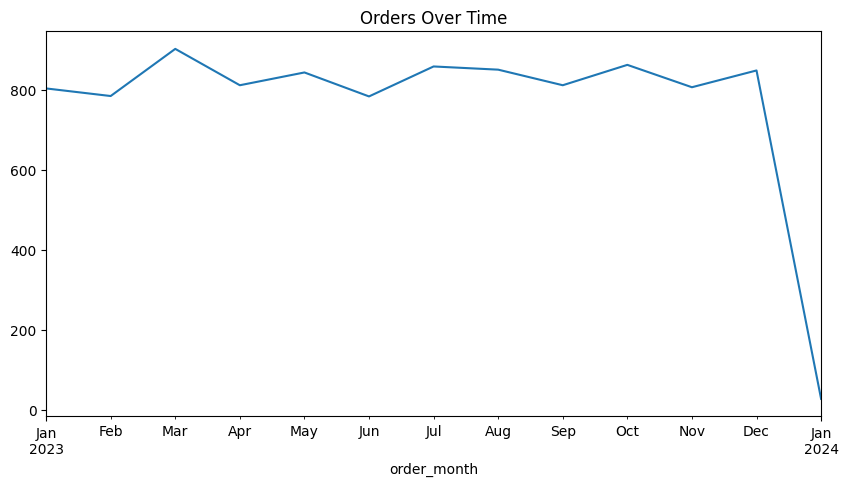

In [31]:
orders_over_time = df.groupby('order_month')['order_id'].count()

orders_over_time.plot(figsize=(10,5), title='Orders Over Time')
plt.show()


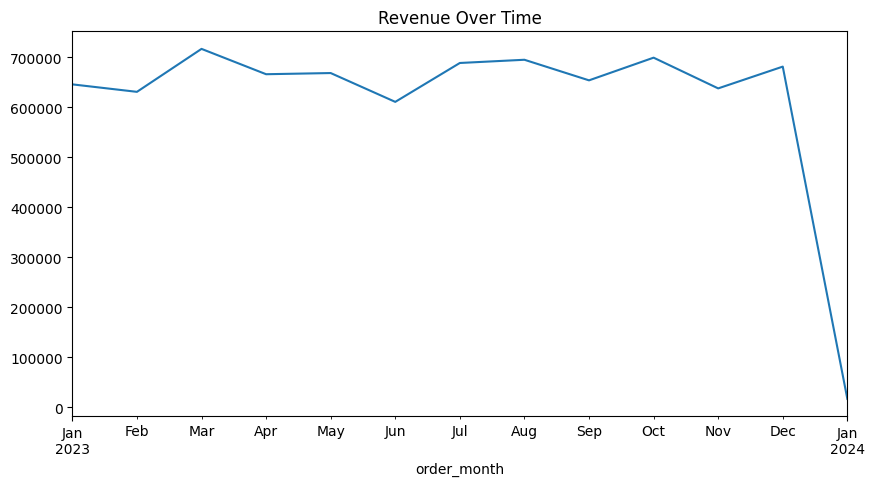

In [33]:
revenue_over_time = df.groupby('order_month')['total_amount'].sum()

revenue_over_time.plot(figsize=(10,5), title='Revenue Over Time')
plt.show()


In [34]:
df.groupby('membership')['order_id'].count()


membership
Gold       4987
Regular    5013
Name: order_id, dtype: int64

In [36]:
df.groupby('membership')['total_amount'].mean()


membership
Gold       797.145556
Regular    805.158434
Name: total_amount, dtype: float64

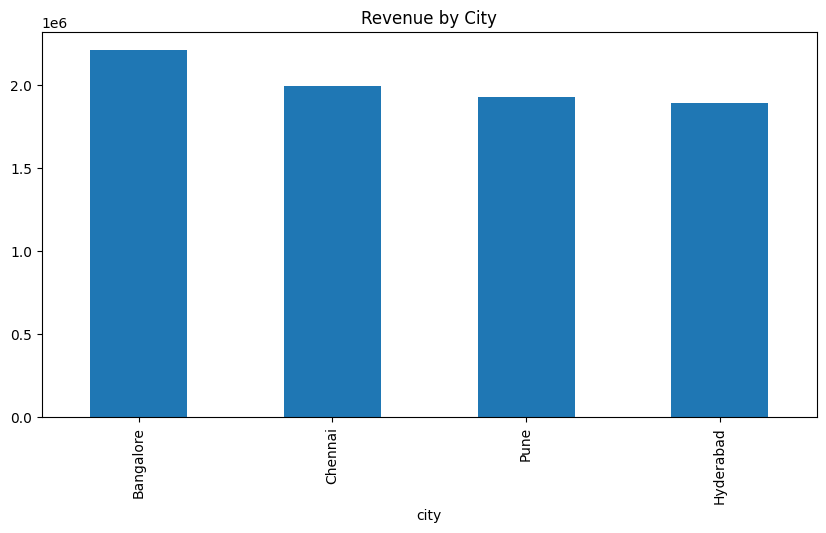

In [39]:
city_revenue = df.groupby('city')['total_amount'].sum().sort_values(ascending=False)
city_revenue.plot(kind='bar', figsize=(10,5), title='Revenue by City')
plt.show()


In [40]:
cuisine_revenue = df.groupby('cuisine')['total_amount'].sum().sort_values(ascending=False)
cuisine_revenue.head(10)


cuisine
Mexican    2085503.09
Italian    2024203.80
Indian     1971412.58
Chinese    1930504.65
Name: total_amount, dtype: float64

In [49]:
df.groupby('cuisine')['total_amount'].mean().sort_values(ascending=False)


cuisine
Mexican    808.021344
Italian    799.448578
Indian     798.466011
Chinese    798.389020
Name: total_amount, dtype: float64

In [51]:
high_value_users = (
    df.groupby('user_id')['total_amount']
    .sum()
)

count_users = (high_value_users > 1000).sum()
count_users


np.int64(2544)

In [52]:
df['rating_bucket'] = pd.cut(
    df['rating'],
    bins=[3.0, 3.5, 4.0, 4.5, 5.0],
    labels=['3.0–3.5', '3.6–4.0', '4.1–4.5', '4.6–5.0']
)

df.groupby('rating_bucket')['total_amount'].sum().sort_values(ascending=False)


C:\Users\jitendra khandelwal\AppData\Local\Temp\ipykernel_27576\572994568.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating_bucket')['total_amount'].sum().sort_values(ascending=False)


rating_bucket
4.6–5.0    2197030.75
4.1–4.5    1960326.26
3.0–3.5    1881754.57
3.6–4.0    1717494.41
Name: total_amount, dtype: float64

In [55]:
(
    df[df['membership'] == 'Gold']
    .groupby('city')['total_amount']
    .mean()
    .sort_values(ascending=False)
)


city
Chennai      808.459080
Hyderabad    806.421034
Bangalore    793.223756
Pune         781.162243
Name: total_amount, dtype: float64

In [60]:
restaurant_count = df.groupby('cuisine')['restaurant_name_x'].nunique()
revenue = df.groupby('cuisine')['total_amount'].sum()

summary = pd.DataFrame({
    'restaurants': restaurant_count,
    'revenue': revenue
}).sort_values(by=['restaurants', 'revenue'], ascending=[True, False])

summary


,restaurants,revenue
cuisine,,
Chinese,115,1930504.65
Indian,122,1971412.58
Mexican,124,2085503.09
Italian,124,2024203.80


In [61]:
gold_orders = df[df['membership'] == 'Gold'].shape[0]
total_orders = df.shape[0]

percentage = round((gold_orders / total_orders) * 100)
percentage


50

In [62]:
restaurant_stats = df.groupby('restaurant_name_x').agg(
    avg_order_value=('total_amount', 'mean'),
    total_orders=('order_id', 'count')
)

restaurant_stats[
    restaurant_stats['total_orders'] < 20
].sort_values(by='avg_order_value', ascending=False)


,avg_order_value,total_orders
restaurant_name_x,,
Hotel Dhaba Multicuisine,1040.222308,13
Sri Mess Punjabi,1029.180833,12
Ruchi Biryani Punjabi,1002.140625,16
Sri Delights Pure Veg,989.467222,18
Classic Kitchen Family Restaurant,973.167895,19
...,...,...
Annapurna Tiffins Punjabi,621.828947,19
Darbar Tiffins Non-Veg,596.815556,18
Darbar Restaurant Punjabi,589.972857,14


In [63]:
df.groupby(['membership', 'cuisine'])['total_amount'].sum().sort_values(ascending=False)


membership  cuisine
Regular     Mexican    1072943.30
            Italian    1018424.75
Gold        Mexican    1012559.79
            Italian    1005779.05
Regular     Indian      992100.27
Gold        Indian      979312.31
            Chinese     977713.74
Regular     Chinese     952790.91
Name: total_amount, dtype: float64

In [64]:
df['quarter'] = df['order_date'].dt.to_period('Q')

df.groupby('quarter')['total_amount'].sum().sort_values(ascending=False)


quarter
2023Q3    2037385.10
2023Q4    2018263.66
2023Q1    1993425.14
2023Q2    1945348.72
2024Q1      17201.50
Freq: Q-DEC, Name: total_amount, dtype: float64

In [65]:
df[df['membership'] == 'Gold'].shape[0]


4987

In [67]:
round(
    df[df['city'] == 'Hyderabad']['total_amount'].sum()
)


1889367

In [68]:
df['user_id'].nunique()


2883

In [69]:
round(
    df[df['membership'] == 'Gold']['total_amount'].mean(),
    2
)


np.float64(797.15)

In [70]:
df[df['rating'] >= 4.5].shape[0]


3374

In [71]:
top_city = (
    df[df['membership'] == 'Gold']
    .groupby('city')['total_amount']
    .sum()
    .idxmax()
)

df[
    (df['membership'] == 'Gold') &
    (df['city'] == top_city)
].shape[0]


1337